# NB01: Data Assembly

Merge AMR gene catalog with ICA module membership and compute full pairwise cofitness.

**Steps:**
1. Verify organism intersection and locusId overlap
2. Map AMR genes to ICA modules (report coverage)
3. Compute full pairwise cofitness from cached fitness matrices
4. Extract support networks at multiple thresholds with operon exclusion
5. Annotate support network genes

**Outputs:** `data/amr_cofitness_partners.csv`, `data/amr_module_membership.csv`

In [1]:
import os
import warnings
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore', category=FutureWarning)

_here = os.path.abspath('')
if os.path.basename(_here) == 'notebooks':
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))
elif os.path.exists(os.path.join(_here, 'projects', 'amr_cofitness_networks')):
    REPO = _here
else:
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))

PROJECT = os.path.join(REPO, 'projects', 'amr_cofitness_networks')
DATA = os.path.join(PROJECT, 'data')
FIGURES = os.path.join(PROJECT, 'figures')
FM_DATA = os.path.join(REPO, 'projects', 'fitness_modules', 'data')
AMR_DATA = os.path.join(REPO, 'projects', 'amr_fitness_cost', 'data')

os.makedirs(DATA, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

# Load AMR data
amr = pd.read_csv(os.path.join(AMR_DATA, 'amr_genes_fb.csv'))
amr_fitness = pd.read_csv(os.path.join(AMR_DATA, 'amr_fitness_noabx.csv'))
amr_fitness['locusId'] = amr_fitness['locusId'].astype(str)

print(f'AMR genes: {len(amr)}, with fitness: {len(amr_fitness)}')
print(f'Organisms: {amr_fitness["orgId"].nunique()}')

AMR genes: 1352, with fitness: 801
Organisms: 28


## 1. Verify organism intersection and locusId overlap

In [2]:
# Find organisms with all three: AMR genes, fitness matrices, ICA modules
amr_orgs = set(amr_fitness['orgId'].unique())
module_files = {os.path.basename(f).replace('_gene_membership.csv', ''): f
                for f in glob(os.path.join(FM_DATA, 'modules', '*_gene_membership.csv'))}
matrix_files = {os.path.basename(f).replace('_fitness_matrix.csv', ''): f
                for f in glob(os.path.join(FM_DATA, 'matrices', '*_fitness_matrix.csv'))}

valid_orgs = sorted(amr_orgs & set(module_files.keys()) & set(matrix_files.keys()))
print(f'Organisms with AMR + modules + matrices: {len(valid_orgs)}')

# Verify locusId overlap per organism
print(f'\nlocusId overlap check:')
org_stats = []
for org in valid_orgs:
    # AMR loci
    org_amr = amr_fitness[amr_fitness['orgId'] == org]
    amr_loci = set(org_amr['locusId'].astype(str))
    
    # Matrix loci
    mat_idx = pd.read_csv(matrix_files[org], usecols=[0]).iloc[:, 0].astype(str)
    mat_loci = set(mat_idx)
    
    # Module loci
    mod_df = pd.read_csv(module_files[org], index_col=0)
    mod_loci = set(mod_df.index.astype(str))
    
    overlap_mat = len(amr_loci & mat_loci)
    overlap_mod = len(amr_loci & mod_loci)
    
    org_stats.append({
        'orgId': org,
        'n_amr': len(amr_loci),
        'n_mat_genes': len(mat_loci),
        'amr_in_matrix': overlap_mat,
        'amr_in_modules': overlap_mod,
        'pct_in_matrix': overlap_mat / len(amr_loci) * 100,
        'pct_in_module_file': overlap_mod / len(amr_loci) * 100  # file-index coverage, NOT module assignment,
    })
    
    flag = ' *** LOW' if overlap_mat / len(amr_loci) < 0.5 else ''
    print(f'  {org:25s}: {len(amr_loci):3d} AMR, {overlap_mat:3d} in matrix '
          f'({overlap_mat/len(amr_loci)*100:5.1f}%), {overlap_mod:3d} in modules '
          f'({overlap_mod/len(amr_loci)*100:5.1f}%){flag}')

org_stats_df = pd.DataFrame(org_stats)
print(f'\nTotal AMR genes in matrices: {org_stats_df["amr_in_matrix"].sum()}')
print(f'Total AMR genes in modules: {org_stats_df["amr_in_modules"].sum()}')
print(f'In module file index: {org_stats_df['amr_in_modules'].sum()}/{org_stats_df['amr_in_matrix'].sum()} AMR genes (note: this is file-index coverage, not module assignment — actual membership computed in NB02)')

Organisms with AMR + modules + matrices: 28

locusId overlap check:
  ANA3                     :  46 AMR,  46 in matrix (100.0%),  46 in modules (100.0%)
  BFirm                    :  50 AMR,  50 in matrix (100.0%),  50 in modules (100.0%)


  Btheta                   :  30 AMR,  30 in matrix (100.0%),  30 in modules (100.0%)


  Caulo                    :  35 AMR,  35 in matrix (100.0%),  35 in modules (100.0%)
  Cup4G11                  :  77 AMR,  77 in matrix (100.0%),  77 in modules (100.0%)
  Dino                     :  30 AMR,  30 in matrix (100.0%),  30 in modules (100.0%)


  DvH                      :  17 AMR,  17 in matrix (100.0%),  17 in modules (100.0%)


  Keio                     :   8 AMR,   8 in matrix (100.0%),   8 in modules (100.0%)
  Korea                    :  36 AMR,  36 in matrix (100.0%),  36 in modules (100.0%)
  Koxy                     :  47 AMR,  47 in matrix (100.0%),  47 in modules (100.0%)


...

  Marino                   :  22 AMR,  22 in matrix (100.0%),  22 in modules (100.0%)
  Methanococcus_JJ         :   2 AMR,   2 in matrix (100.0%),   2 in modules (100.0%)
  Methanococcus_S2         :   2 AMR,   2 in matrix (100.0%),   2 in modules (100.0%)
  PV4                      :  21 AMR,  21 in matrix (100.0%),  21 in modules (100.0%)
  Pedo557                  :   1 AMR,   1 in matrix (100.0%),   1 in modules (100.0%)


  Phaeo                    :  17 AMR,  17 in matrix (100.0%),  17 in modules (100.0%)


  Ponti                    :  32 AMR,  32 in matrix (100.0%),  32 in modules (100.0%)
  Putida                   :  47 AMR,  47 in matrix (100.0%),  47 in modules (100.0%)
  SynE                     :  11 AMR,  11 in matrix (100.0%),  11 in modules (100.0%)
  WCS417                   :  32 AMR,  32 in matrix (100.0%),  32 in modules (100.0%)


  acidovorax_3H11          :  28 AMR,  28 in matrix (100.0%),  28 in modules (100.0%)
  psRCH2                   :  30 AMR,  30 in matrix (100.0%),  30 in modules (100.0%)
  pseudo13_GW456_L13       :  38 AMR,  38 in matrix (100.0%),  38 in modules (100.0%)
  pseudo1_N1B4             :  30 AMR,  30 in matrix (100.0%),  30 in modules (100.0%)


  pseudo3_N2E3             :  28 AMR,  28 in matrix (100.0%),  28 in modules (100.0%)
  pseudo5_N2C3_1           :  30 AMR,  30 in matrix (100.0%),  30 in modules (100.0%)
  pseudo6_N2E2             :  32 AMR,  32 in matrix (100.0%),  32 in modules (100.0%)

Total AMR genes in matrices: 801
Total AMR genes in modules: 801
Module coverage: 100.0% of AMR genes with fitness data


## 2. Map AMR genes to ICA modules

In [3]:
# For each AMR gene, find its ICA module membership
module_assignments = []

for org in valid_orgs:
    mod_df = pd.read_csv(module_files[org], index_col=0)
    mod_df.index = mod_df.index.astype(str)
    
    org_amr = amr_fitness[amr_fitness['orgId'] == org]
    
    for _, row in org_amr.iterrows():
        locus = str(row['locusId'])
        if locus not in mod_df.index:
            module_assignments.append({
                'orgId': org, 'locusId': locus,
                'module': None, 'in_module': False,
                'amr_class': row['amr_class'],
                'amr_mechanism': row['amr_mechanism'],
                'mean_fitness': row['mean_fitness'],
            })
            continue
        
        gene_memberships = mod_df.loc[locus]
        assigned_modules = gene_memberships[gene_memberships == 1].index.tolist()
        
        if assigned_modules:
            for mod in assigned_modules:
                module_assignments.append({
                    'orgId': org, 'locusId': locus,
                    'module': mod, 'in_module': True,
                    'amr_class': row['amr_class'],
                    'amr_mechanism': row['amr_mechanism'],
                    'mean_fitness': row['mean_fitness'],
                })
        else:
            module_assignments.append({
                'orgId': org, 'locusId': locus,
                'module': None, 'in_module': False,
                'amr_class': row['amr_class'],
                'amr_mechanism': row['amr_mechanism'],
                'mean_fitness': row['mean_fitness'],
            })

mod_assign_df = pd.DataFrame(module_assignments)

# Deduplicate for counting: one row per gene (may have multiple modules)
gene_level = mod_assign_df.drop_duplicates(subset=['orgId', 'locusId'])
in_mod = mod_assign_df[mod_assign_df['in_module']].drop_duplicates(subset=['orgId', 'locusId'])

print(f'AMR genes total: {len(gene_level)}')
print(f'AMR genes in at least one module: {len(in_mod)} ({len(in_mod)/len(gene_level)*100:.1f}%)')
print(f'AMR genes NOT in any module: {len(gene_level) - len(in_mod)}')

print(f'\nModule coverage by mechanism:')
for mech in ['efflux', 'enzymatic_inactivation', 'metal_resistance', 'unknown']:
    total = len(gene_level[gene_level['amr_mechanism'] == mech])
    in_m = len(in_mod[in_mod['amr_mechanism'] == mech])
    pct = in_m / total * 100 if total > 0 else 0
    print(f'  {mech:30s}: {in_m}/{total} ({pct:.1f}%)')

# Save module assignments
mod_assign_df.to_csv(os.path.join(DATA, 'amr_module_membership.csv'), index=False)
print(f'\nSaved to data/amr_module_membership.csv')

AMR genes total: 801
AMR genes in at least one module: 192 (24.0%)
AMR genes NOT in any module: 609

Module coverage by mechanism:
  efflux                        : 75/254 (29.5%)
  enzymatic_inactivation        : 59/304 (19.4%)
  metal_resistance              : 32/144 (22.2%)
  unknown                       : 19/74 (25.7%)

Saved to data/amr_module_membership.csv


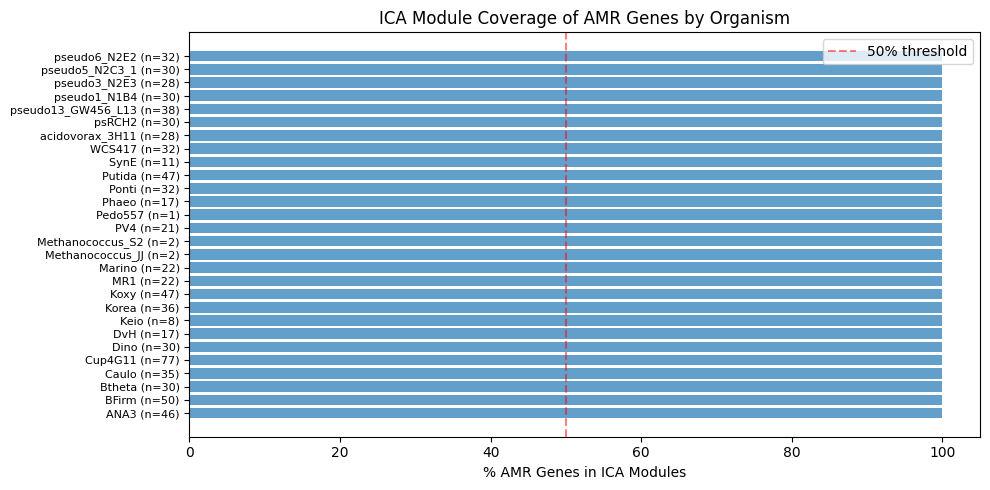

Saved to figures/amr_module_coverage.png


In [4]:
# Module coverage bar chart
fig, ax = plt.subplots(figsize=(10, 5))

coverage = org_stats_df.sort_values('pct_in_modules', ascending=True)
bars = ax.barh(range(len(coverage)), coverage['pct_in_modules'], color='tab:blue', alpha=0.7)
ax.set_yticks(range(len(coverage)))
ax.set_yticklabels([f"{r['orgId']} (n={r['n_amr']:.0f})" for _, r in coverage.iterrows()], fontsize=8)
ax.set_xlabel('% AMR Genes in ICA Modules')
ax.set_title('ICA Module Coverage of AMR Genes by Organism')
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'amr_module_coverage.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved to figures/amr_module_coverage.png')

## 3. Compute full pairwise cofitness from cached fitness matrices

In [5]:
# For each organism, compute Pearson correlation between each AMR gene's
# fitness profile and all other genes' profiles
# This replaces the cofit table (which only stores top ~96 partners)

all_partners = []

for i, org in enumerate(valid_orgs):
    # Load fitness matrix
    fit_mat = pd.read_csv(matrix_files[org], index_col=0)
    fit_mat.index = fit_mat.index.astype(str)
    fit_mat = fit_mat.apply(pd.to_numeric, errors='coerce')
    
    # Get AMR loci in this matrix
    org_amr = amr_fitness[amr_fitness['orgId'] == org]
    amr_loci = [str(l) for l in org_amr['locusId'] if str(l) in fit_mat.index]
    
    if len(amr_loci) == 0:
        continue
    
    # Get gene positions for operon exclusion
    # Use index position as a proxy for genomic order (loci are roughly ordered)
    all_loci = list(fit_mat.index)
    locus_to_idx = {l: j for j, l in enumerate(all_loci)}
    
    # Compute correlation matrix: AMR genes (rows) vs all genes (columns)
    amr_profiles = fit_mat.loc[amr_loci]
    # Drop columns with all NaN to avoid warnings
    valid_cols = fit_mat.columns[fit_mat.notna().any()]
    corr_matrix = amr_profiles[valid_cols].T.corrwith(fit_mat[valid_cols].T)
    
    # Actually, we need per-AMR-gene correlations with ALL other genes
    # corrwith gives one series; we need a matrix
    # Use numpy for speed
    amr_mat = fit_mat.loc[amr_loci].values  # (n_amr, n_exps)
    all_mat = fit_mat.values  # (n_genes, n_exps)
    
    # Standardize (for Pearson)
    amr_std = (amr_mat - np.nanmean(amr_mat, axis=1, keepdims=True))
    amr_norms = np.sqrt(np.nansum(amr_std**2, axis=1, keepdims=True))
    amr_norms[amr_norms == 0] = 1
    amr_std = amr_std / amr_norms
    
    all_std = (all_mat - np.nanmean(all_mat, axis=1, keepdims=True))
    all_norms = np.sqrt(np.nansum(all_std**2, axis=1, keepdims=True))
    all_norms[all_norms == 0] = 1
    all_std = all_std / all_norms
    
    # Replace NaN with 0 for dot product
    amr_std = np.nan_to_num(amr_std, 0)
    all_std = np.nan_to_num(all_std, 0)
    
    # Pearson correlation matrix: (n_amr, n_genes)
    corr = amr_std @ all_std.T
    
    # Extract support partners at |r| > 0.3
    for ai, amr_locus in enumerate(amr_loci):
        amr_idx = locus_to_idx.get(amr_locus, -1)
        amr_info = org_amr[org_amr['locusId'].astype(str) == amr_locus].iloc[0]
        
        for gi, gene_locus in enumerate(all_loci):
            if gene_locus == amr_locus:
                continue  # skip self
            
            r = corr[ai, gi]
            if abs(r) < 0.3:
                continue
            
            # Operon exclusion: within 5 ORFs on same strand (index proximity)
            gene_idx = locus_to_idx.get(gene_locus, -1)
            orf_distance = abs(gene_idx - amr_idx) if amr_idx >= 0 and gene_idx >= 0 else 999
            is_near = orf_distance <= 5
            
            all_partners.append({
                'orgId': org,
                'amr_locusId': amr_locus,
                'partner_locusId': gene_locus,
                'cofitness': r,
                'abs_cofitness': abs(r),
                'orf_distance': orf_distance,
                'is_near_operon': is_near,
                'amr_mechanism': amr_info['amr_mechanism'],
                'amr_class': amr_info['amr_class'],
            })
    
    if (i + 1) % 5 == 0 or i == len(valid_orgs) - 1:
        print(f'  Processed {i+1}/{len(valid_orgs)} organisms, '
              f'{len(all_partners):,} partners so far')

partners_df = pd.DataFrame(all_partners)
print(f'\nTotal cofitness partners (|r| > 0.3): {len(partners_df):,}')
print(f'  Near-operon (<=5 ORFs): {partners_df["is_near_operon"].sum():,}')
print(f'  Extra-operon (>5 ORFs): {(~partners_df["is_near_operon"]).sum():,}')

  Processed 5/28 organisms, 92,514 partners so far


  Processed 10/28 organisms, 114,432 partners so far


  Processed 15/28 organisms, 133,633 partners so far


  Processed 20/28 organisms, 160,142 partners so far


  Processed 25/28 organisms, 174,389 partners so far


  Processed 28/28 organisms, 180,370 partners so far

Total cofitness partners (|r| > 0.3): 180,370
  Near-operon (<=5 ORFs): 995
  Extra-operon (>5 ORFs): 179,375


In [6]:
# Summary statistics
extra_operon = partners_df[~partners_df['is_near_operon']]

print('=== Support network size distribution (extra-operon, |r| > 0.3) ===')
net_sizes = extra_operon.groupby(['orgId', 'amr_locusId']).size()
print(f'AMR genes with >=1 extra-operon partner: {len(net_sizes)} / {len(amr_fitness)}')
print(f'Network size: mean={net_sizes.mean():.1f}, median={net_sizes.median():.0f}, '
      f'max={net_sizes.max()}')

# By threshold
for threshold in [0.3, 0.4, 0.5]:
    subset = extra_operon[extra_operon['abs_cofitness'] >= threshold]
    sizes = subset.groupby(['orgId', 'amr_locusId']).size()
    n_with = len(sizes)
    mean_s = sizes.mean() if len(sizes) > 0 else 0
    print(f'  |r| >= {threshold}: {n_with} AMR genes with partners, '
          f'mean size = {mean_s:.1f}')

=== Support network size distribution (extra-operon, |r| > 0.3) ===


AMR genes with >=1 extra-operon partner: 769 / 801
Network size: mean=233.3, median=84, max=2021
  |r| >= 0.3: 769 AMR genes with partners, mean size = 233.3
  |r| >= 0.4: 593 AMR genes with partners, mean size = 109.9
  |r| >= 0.5: 336 AMR genes with partners, mean size = 70.7


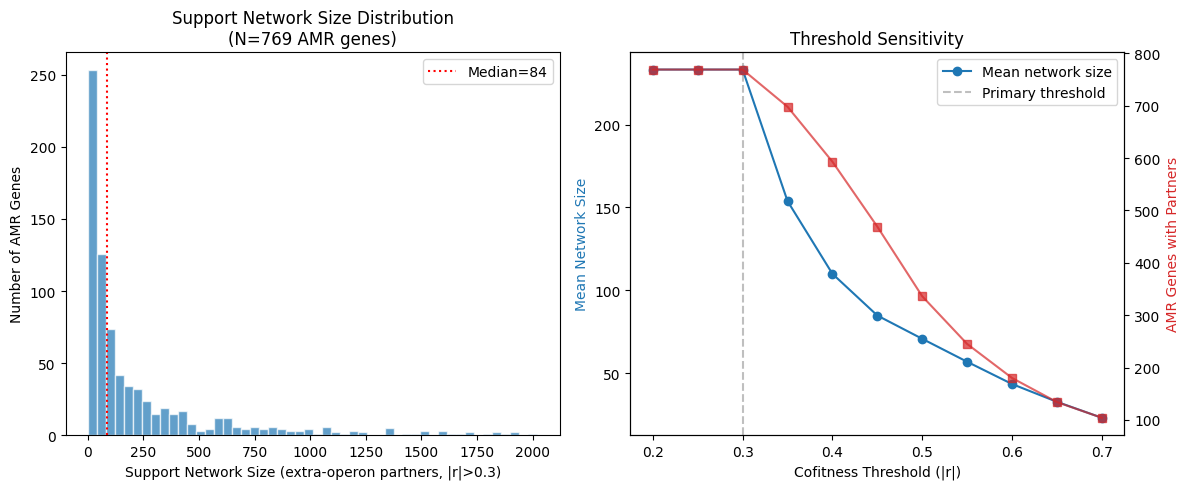

Saved to figures/cofitness_threshold_sensitivity.png


In [7]:
# Cofitness threshold sensitivity plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: distribution of extra-operon partner counts at |r| > 0.3
ax = axes[0]
ax.hist(net_sizes.values, bins=50, alpha=0.7, color='tab:blue', edgecolor='white')
ax.set_xlabel('Support Network Size (extra-operon partners, |r|>0.3)')
ax.set_ylabel('Number of AMR Genes')
ax.set_title(f'Support Network Size Distribution\n(N={len(net_sizes)} AMR genes)')
ax.axvline(net_sizes.median(), color='red', linestyle=':', label=f'Median={net_sizes.median():.0f}')
ax.legend()

# Right: sensitivity across thresholds
ax = axes[1]
thresholds = np.arange(0.2, 0.71, 0.05)
mean_sizes = []
n_genes_with = []
for t in thresholds:
    sub = extra_operon[extra_operon['abs_cofitness'] >= t]
    sizes = sub.groupby(['orgId', 'amr_locusId']).size()
    mean_sizes.append(sizes.mean() if len(sizes) > 0 else 0)
    n_genes_with.append(len(sizes))

ax.plot(thresholds, mean_sizes, 'o-', color='tab:blue', label='Mean network size')
ax2 = ax.twinx()
ax2.plot(thresholds, n_genes_with, 's-', color='tab:red', alpha=0.7, label='AMR genes with partners')
ax.set_xlabel('Cofitness Threshold (|r|)')
ax.set_ylabel('Mean Network Size', color='tab:blue')
ax2.set_ylabel('AMR Genes with Partners', color='tab:red')
ax.set_title('Threshold Sensitivity')
ax.axvline(0.3, color='gray', linestyle='--', alpha=0.5, label='Primary threshold')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'cofitness_threshold_sensitivity.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved to figures/cofitness_threshold_sensitivity.png')

## 4. Annotate support network genes

In [8]:
# Load gene annotations for each organism
# Annotations are in separate files: *_genes.csv (desc), *_seed.csv (SEED), *_kegg.csv (KEGG)

all_annotations = []
for org in valid_orgs:
    genes_f = os.path.join(FM_DATA, 'annotations', f'{org}_genes.csv')
    seed_f = os.path.join(FM_DATA, 'annotations', f'{org}_seed.csv')
    kegg_f = os.path.join(FM_DATA, 'annotations', f'{org}_kegg.csv')
    
    if not os.path.exists(genes_f):
        continue
    
    genes = pd.read_csv(genes_f)
    genes['locusId'] = genes['locusId'].astype(str)
    genes['orgId'] = org
    
    # Merge SEED
    if os.path.exists(seed_f):
        seed = pd.read_csv(seed_f)
        seed['locusId'] = seed['locusId'].astype(str)
        genes = genes.merge(seed, on='locusId', how='left')
    
    # Merge KEGG
    if os.path.exists(kegg_f):
        kegg = pd.read_csv(kegg_f)
        kegg['locusId'] = kegg['locusId'].astype(str)
        # Take first KEGG group per gene (some have multiple)
        kegg = kegg.drop_duplicates(subset=['locusId'], keep='first')
        genes = genes.merge(kegg[['locusId', 'kgroup', 'kgroup_desc']], on='locusId', how='left')
    
    all_annotations.append(genes)

annotations = pd.concat(all_annotations, ignore_index=True)
print(f'Gene annotations loaded: {len(annotations)} genes across {annotations["orgId"].nunique()} organisms')
print(f'Columns: {list(annotations.columns)}')
print(f'With desc: {annotations["desc"].notna().sum()}')
print(f'With SEED: {annotations["seed_desc"].notna().sum() if "seed_desc" in annotations.columns else 0}')
print(f'With KEGG: {annotations["kgroup"].notna().sum() if "kgroup" in annotations.columns else 0}')


Gene annotations loaded: 133734 genes across 28 organisms
Columns: ['locusId', 'sysName', 'gene', 'desc', 'scaffoldId', 'begin', 'end', 'strand', 'orgId', 'seed_desc', 'kgroup', 'kgroup_desc']
With desc: 132711
With SEED: 105056
With KEGG: 59754


In [9]:
# Merge annotations into the partner table
annot_cols = ['orgId', 'locusId', 'desc']
rename_map = {'locusId': 'partner_locusId', 'desc': 'partner_desc'}
if 'seed_desc' in annotations.columns:
    annot_cols.append('seed_desc')
    rename_map['seed_desc'] = 'partner_seed_desc'
if 'kgroup' in annotations.columns:
    annot_cols.append('kgroup')
    annot_cols.append('kgroup_desc')
    rename_map['kgroup'] = 'partner_kgroup'
    rename_map['kgroup_desc'] = 'partner_kgroup_desc'

partners_annotated = partners_df.merge(
    annotations[annot_cols].rename(columns=rename_map),
    on=['orgId', 'partner_locusId'], how='left'
)

print(f'Partners with desc: {partners_annotated["partner_desc"].notna().sum()} / {len(partners_annotated)}')
if 'partner_seed_desc' in partners_annotated.columns:
    print(f'Partners with SEED: {partners_annotated["partner_seed_desc"].notna().sum()}')
if 'partner_kgroup' in partners_annotated.columns:
    print(f'Partners with KEGG: {partners_annotated["partner_kgroup"].notna().sum()}')

# Save
partners_annotated.to_csv(os.path.join(DATA, 'amr_cofitness_partners.csv'), index=False)
print(f'\nSaved {len(partners_annotated):,} partner records to data/amr_cofitness_partners.csv')


Partners with desc: 180047 / 180370
Partners with SEED: 141713
Partners with KEGG: 74061



Saved 180,370 partner records to data/amr_cofitness_partners.csv


## 5. Summary

In [10]:
print('=== NB01 Data Assembly Summary ===')
print(f'Organisms: {len(valid_orgs)}')
print(f'AMR genes with fitness data: {len(amr_fitness)}')
print(f'AMR genes in ICA modules: {len(in_mod)} ({len(in_mod)/len(gene_level)*100:.1f}%)')
print(f'Total cofitness partners (|r|>0.3): {len(partners_df):,}')
print(f'  Extra-operon: {(~partners_df["is_near_operon"]).sum():,}')
print(f'  Near-operon (excluded): {partners_df["is_near_operon"].sum():,}')
extra = partners_df[~partners_df['is_near_operon']]
sizes = extra.groupby(['orgId', 'amr_locusId']).size()
print(f'AMR genes with extra-operon partners: {len(sizes)}')
print(f'Mean support network size: {sizes.mean():.1f}')
print(f'\nReady for NB02 (module analysis) and NB03 (support network characterization)')

=== NB01 Data Assembly Summary ===
Organisms: 28
AMR genes with fitness data: 801
AMR genes in ICA modules: 192 (24.0%)
Total cofitness partners (|r|>0.3): 180,370
  Extra-operon: 179,375
  Near-operon (excluded): 995
AMR genes with extra-operon partners: 769
Mean support network size: 233.3

Ready for NB02 (module analysis) and NB03 (support network characterization)
